## Offensive Performance and Home Advantage in European Football

## Introduction

This project explores offensive performance patterns and match outcomes across European football leagues using historical match data.

The goal is to identify patterns in goal scoring, evaluate the impact of playing at home, and compare offensive production across teams and leagues.

## Objective
To analyze football match data in order to:
- Identify differences in goal production across leagues
- Evaluate the strength of home advantage
- Determine which teams generate the highest offensive putput

## Dataset

The dataset contains historical football match data from multiple European leagues, including information about teams, goals scored, match outcomes, and league identifiers.

The data is stored in a relational database (SQLite) and includes multiple tables such as Match, League, Team and Player.

## Feature Engineering

A new variable, `total_goals`, was created to represent the total number of goals in each match:

- total_goals = home+team_goal + away_team_goal

This variable will be used to analyze scoring patterns across leagues.

In [51]:
import sqlite3
import pandas as pd

In [52]:
conn = sqlite3.connect("../data/database.sqlite")

In [53]:
query = "SELECT name FROM sqlite_master WHERE type = 'table';"
tables = pd.read_sql(query, conn)
tables

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


In [54]:
query = "PRAGMA table_info(Match);"
match_columns = pd.read_sql(query, conn)
match_columns

,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,country_id,INTEGER,0,None,0
2,2,league_id,INTEGER,0,None,0
3,3,season,TEXT,0,None,0
4,4,stage,INTEGER,0,None,0
...,...,...,...,...,...,...
110,110,GBD,NUMERIC,0,None,0
111,111,GBA,NUMERIC,0,None,0
112,112,BSH,NUMERIC,0,None,0
113,113,BSD,NUMERIC,0,None,0


In [55]:
match_columns['name']

0              id
1      country_id
2       league_id
3          season
4           stage
          ...    
110           GBD
111           GBA
112           BSH
113           BSD
114           BSA
Name: name, Length: 115, dtype: object

In [56]:
query = "SELECT * FROM Match LIMIT 5;"
df_match = pd.read_sql(query, conn)
df_match

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [57]:
columns_to_keep = [
    'season',
    'date',
    'league_id',
    'home_team_api_id',
    'away_team_api_id',
    'home_team_goal',
    'away_team_goal'
]

df_match = df_match[columns_to_keep]
df_match

,season,date,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,2008/2009,2008-08-17 00:00:00,1,9987,9993,1,1
1,2008/2009,2008-08-16 00:00:00,1,10000,9994,0,0
2,2008/2009,2008-08-16 00:00:00,1,9984,8635,0,3
3,2008/2009,2008-08-17 00:00:00,1,9991,9998,5,0
4,2008/2009,2008-08-16 00:00:00,1,7947,9985,1,3


In [58]:
query = """
SELECT 
    season,
    date,
    league_id,
    home_team_api_id,
    away_team_api_id,
    home_team_goal,
    away_team_goal
FROM Match
"""

df_match = pd.read_sql(query, conn)
df_match.head()

,season,date,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,2008/2009,2008-08-17 00:00:00,1,9987,9993,1,1
1,2008/2009,2008-08-16 00:00:00,1,10000,9994,0,0
2,2008/2009,2008-08-16 00:00:00,1,9984,8635,0,3
3,2008/2009,2008-08-17 00:00:00,1,9991,9998,5,0
4,2008/2009,2008-08-16 00:00:00,1,7947,9985,1,3


In [59]:
df_match['total_goals'] = df_match['home_team_goal'] + df_match['away_team_goal']
df_match.head()

,season,date,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,total_goals
0,2008/2009,2008-08-17 00:00:00,1,9987,9993,1,1,2
1,2008/2009,2008-08-16 00:00:00,1,10000,9994,0,0,0
2,2008/2009,2008-08-16 00:00:00,1,9984,8635,0,3,3
3,2008/2009,2008-08-17 00:00:00,1,9991,9998,5,0,5
4,2008/2009,2008-08-16 00:00:00,1,7947,9985,1,3,4


## Goal Patterns Across Leagues

This analysis examines the average number of goals scored per match across different European football leagues.

By aggregating total goals at the league level, we can identify which leagues tend to have more offensively active matches.

In [60]:
query = "SELECT id, name FROM League;"
df_league = pd.read_sql(query, conn)
df_league.head()


,id,name
0,1,Belgium Jupiler League
1,1729,England Premier League
2,4769,France Ligue 1
3,7809,Germany 1. Bundesliga
4,10257,Italy Serie A


In [61]:
df_match = df_match.merge(
    df_league,
    left_on='league_id',
    right_on='id',
    how='left'
)

df_match.head()

,season,date,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,total_goals,id,name
0,2008/2009,2008-08-17 00:00:00,1,9987,9993,1,1,2,1,Belgium Jupiler League
1,2008/2009,2008-08-16 00:00:00,1,10000,9994,0,0,0,1,Belgium Jupiler League
2,2008/2009,2008-08-16 00:00:00,1,9984,8635,0,3,3,1,Belgium Jupiler League
3,2008/2009,2008-08-17 00:00:00,1,9991,9998,5,0,5,1,Belgium Jupiler League
4,2008/2009,2008-08-16 00:00:00,1,7947,9985,1,3,4,1,Belgium Jupiler League


In [62]:
goals_by_league = df_match.groupby('name')['total_goals'].mean().sort_values(ascending=False)
goals_by_league

name
Netherlands Eredivisie      3.080882
Switzerland Super League    2.929677
Germany 1. Bundesliga       2.901552
Belgium Jupiler League      2.801505
Spain LIGA BBVA             2.767105
England Premier League      2.710526
Scotland Premier League     2.633772
Italy Serie A               2.616838
Portugal Liga ZON Sagres    2.534600
France Ligue 1              2.443092
Poland Ekstraklasa          2.425000
Name: total_goals, dtype: float64

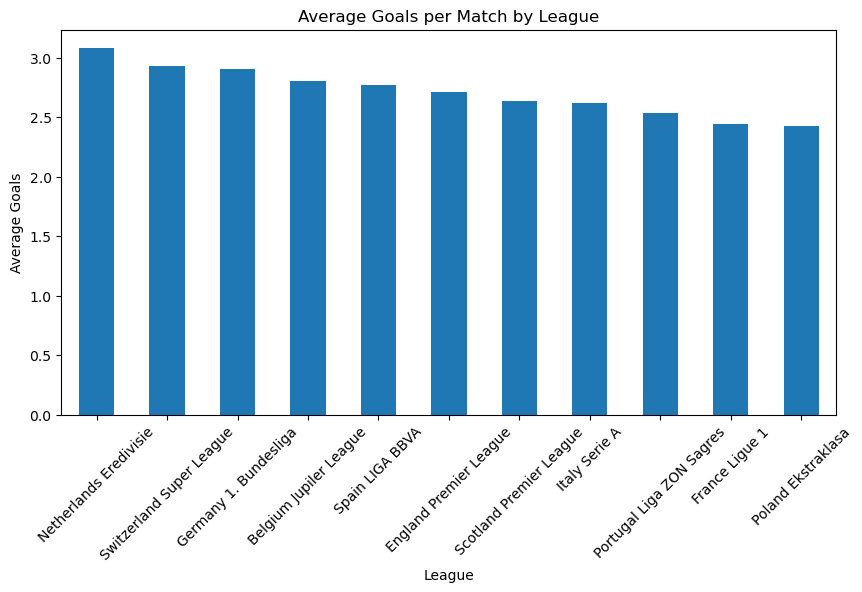

In [77]:
import matplotlib.pyplot as plt

goals_by_league.plot(kind='bar', figsize=(10,5))
plt.title('Average Goals per Match by League')
plt.ylabel('Average Goals')
plt.xlabel('League')
plt.xticks(rotation=45)

plt.savefig('../images/goals_by_league.png', bbox_inches='tight')

plt.show()

### Key Findings

- The variation in average goals per match across leagues is relatively small.
- The highest-scoring league averages around 3.08 goals per match, while the lowest is approximately 2.42.
- No significant outliers are observed, suggesting that scoring patterns are fairly consistent across leagues.

### Interpretation

The similarity in goal averages indicates that, despite differences in playing styles and competition levels, European leagues tend to produce comparable offensive outputs. This suggests a level of balance in goal-scoring dynamics across competitions.

## Match Result Distribution - Home Advantage Analysis

This section analyzes the distribution of match outcomes to evaluate the presence and strength of home advantage in European football.

Each match is classified into three possible outcomes:
- Home Win
- Away Win
- Draw

By examining the proportion of each result, we can better understand how playing at home influences match outcomes.


In [64]:
import numpy as np

df_match['result'] = np.where(
    df_match['home_team_goal'] > df_match['away_team_goal'], 'Home Win',
    np.where(
        df_match['home_team_goal'] < df_match['away_team_goal'], 'Away Win',
        'Draw'
    )
)

df_match.head()

,season,date,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,total_goals,id,name,result
0,2008/2009,2008-08-17 00:00:00,1,9987,9993,1,1,2,1,Belgium Jupiler League,Draw
1,2008/2009,2008-08-16 00:00:00,1,10000,9994,0,0,0,1,Belgium Jupiler League,Draw
2,2008/2009,2008-08-16 00:00:00,1,9984,8635,0,3,3,1,Belgium Jupiler League,Away Win
3,2008/2009,2008-08-17 00:00:00,1,9991,9998,5,0,5,1,Belgium Jupiler League,Home Win
4,2008/2009,2008-08-16 00:00:00,1,7947,9985,1,3,4,1,Belgium Jupiler League,Away Win


In [65]:
result_distribution = df_match['result'].value_counts(normalize=True) * 100
result_distribution

result
Home Win    45.871666
Away Win    28.738597
Draw        25.389738
Name: proportion, dtype: float64

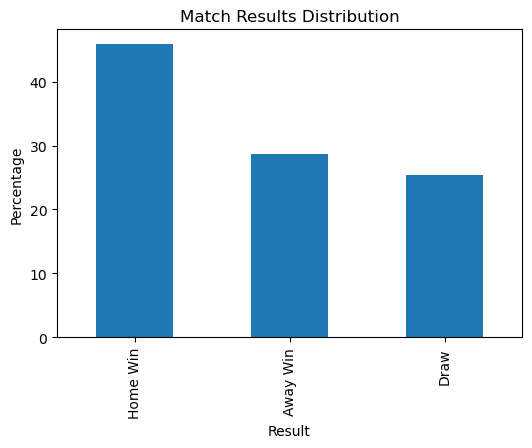

In [66]:
result_distribution.plot(kind='bar', figsize=(6,4))
plt.title('Match Results Distribution')
plt.ylabel('Percentage')
plt.xlabel('Result')

plt.savefig('../images/match_results_distribution.png', bbox_inches='tight')

plt.show()

In [67]:
home_vs_away = result_distribution[['Home Win', 'Away Win']]
home_vs_away

result
Home Win    45.871666
Away Win    28.738597
Name: proportion, dtype: float64

### Key Findings

- Home teams wins approximately 46% of matches
- Away teams win around 29% of matches
- Draws account for roughly 25% of all outcomes.

### Interpretation

The results show a clear home advantage, with home teams winning significantly more matches than away teams. The difference between home and away wins is substantial, indicating that playing at home provides a meaningful competitive edge. Interestingly, draws and away wins occur at relatively similar rates, suggesting that the main imbalance in match outcomes is driven by the advantage of playing at home rather than a large difference between losing and drawing outcomes. Despite this advantage, more than half of the matches do not result in a home win, indicating that match outcomes remain competitive and not fully determined by venue.

## Top Scoring Teams


In [68]:
home_goals = df_match.groupby('home_team_api_id')['home_team_goal'].sum()
home_goals.head()

home_team_api_id
1601    148
1773     74
1957    176
2033     70
2182    215
Name: home_team_goal, dtype: int64

In [69]:
away_goals = df_match.groupby('away_team_api_id')['away_team_goal'].sum()
away_goals.head()

away_team_api_id
1601    132
1773     52
1957    111
2033     68
2182    157
Name: away_team_goal, dtype: int64

In [70]:
total_goals_team = home_goals.add(away_goals, fill_value=0)
total_goals_team.head()

home_team_api_id
1601    280
1773    126
1957    287
2033    138
2182    372
dtype: int64

In [71]:
total_goals_team = total_goals_team.sort_values(ascending=False)
total_goals_team.head(10)

home_team_api_id
8634     849
8633     843
9925     695
9823     653
8640     652
8593     647
9931     619
8456     606
8455     583
10260    582
dtype: int64

In [72]:
query = "SELECT team_api_id, team_long_name FROM Team;"
df_team = pd.read_sql(query, conn)
df_team.head(10)

,team_api_id,team_long_name
0,9987,KRC Genk
1,9993,Beerschot AC
2,10000,SV Zulte-Waregem
3,9994,Sporting Lokeren
4,9984,KSV Cercle Brugge
5,8635,RSC Anderlecht
6,9991,KAA Gent
7,9998,RAEC Mons
8,7947,FCV Dender EH
9,9985,Standard de Liège


In [73]:
df_goals_team = total_goals_team.reset_index()
df_goals_team.columns = ['team_api_id', 'total_goals']
df_goals_team.head(10)

,team_api_id,total_goals
0,8634,849
1,8633,843
2,9925,695
3,9823,653
4,8640,652
5,8593,647
6,9931,619
7,8456,606
8,8455,583
9,10260,582


In [74]:
df_goals_team = df_goals_team.merge(df_team, on='team_api_id', how='left')
df_goals_team.head(10)

,team_api_id,total_goals,team_long_name
0,8634,849,FC Barcelona
1,8633,843,Real Madrid CF
2,9925,695,Celtic
3,9823,653,FC Bayern Munich
4,8640,652,PSV
5,8593,647,Ajax
6,9931,619,FC Basel
7,8456,606,Manchester City
8,8455,583,Chelsea
9,10260,582,Manchester United


In [75]:
df_goals_team [['team_long_name', 'total_goals']].head(10)

,team_long_name,total_goals
0,FC Barcelona,849
1,Real Madrid CF,843
2,Celtic,695
3,FC Bayern Munich,653
4,PSV,652
5,Ajax,647
6,FC Basel,619
7,Manchester City,606
8,Chelsea,583
9,Manchester United,582


## Top Scoring Teams

This section identifies the teams with the highest offensive putput based on total goals scored. To capture overall attacking performance, goals scored as both home and away teams were aggregated for each team. This provides a more complete view of offensive production across all matches. The top teams are then ranked based on total goals scored.

<function matplotlib.pyplot.show(close=None, block=None)>

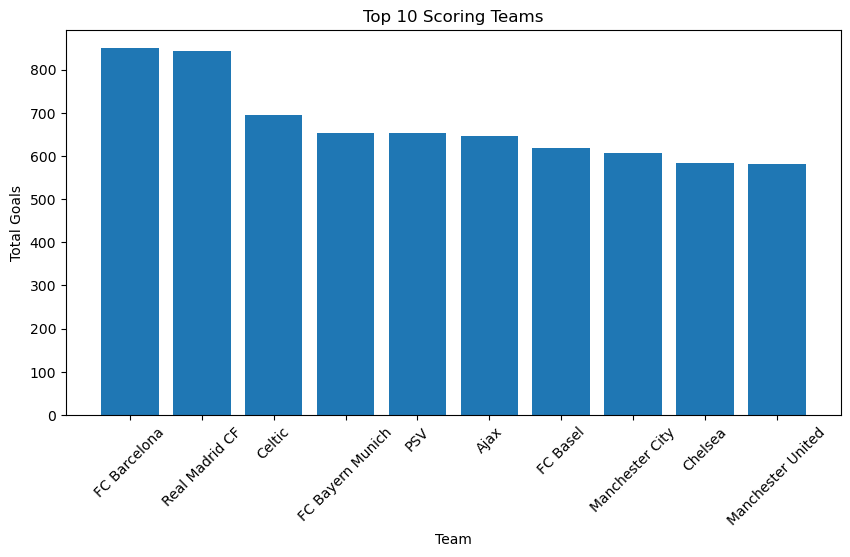

In [76]:
top_10 = df_goals_team[['team_long_name', 'total_goals']].head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top_10['team_long_name'], top_10['total_goals'])
plt.title('Top 10 Scoring Teams')
plt.xlabel('Team')
plt.ylabel('Total Goals')
plt.xticks(rotation=45)

plt.savefig('../images/top_scoring_teams.png', bbox_inches='tight')

plt.show

### Key Findings

- Teams such as FC Barcelona, Real Madrid and Celtic rank amongst the highest in total goals scored.

- These teams are historically dominant within their respective leagues, which is reflected in the offensive output.

- There is a noticeable gap between top-performing teams and the rest, indicating that goal production is concentrated among a subset of clubs.

### Interpretation

The result suggest that offensive production is not evenly distributed across teams. Instead, a small number of high-performing clubs account for a disproportionate share of total goals.

This pattern is consistent with comptitive imbalances often observed in top European leagues, where stronger teams maintain sustained offensive dominance over time.

## Conclusion

This analysis explored offensive performance and match outcomes across European football leagues using historical match data.

The results show that goal-scoring patterns are relatively consistent across leagues, with only minor differences in average goals per match. This suggest that, despite variations in playing styles and competition levels, offensive output remains broadly similar across European competitions.

A clear home advantage was identified, with some teams winning significantly more matches than away teams. However, more than half of all matches do not result in a home win, indicating that match outcome remain competitive and are not solely determined by venue.

At the team level, offensive production is concentrated among a small group of high-performing clubs. Teams such as FC Barcelona, Real Madrid and Celtic consistenly rank among the top in total goals scored, reflecting sustained dominance with their leagues.

### Limitations

- The analysis does not account for expected goals (xG), which would provide deeper insight into the chance quality.
- Team strength is inferred from outcomes rather than directly measured using player-level data.
- Differences across seasons and league-specific dynamics are not fully explored.
 
### Next Steps

- Incorporate player-level data to evaluate the relationship between squad quality and offensive performance.
- Include expected goals (xG) to assess efficiency and chance creation.
- Analyze trends over time to identify changes in scoring patterns and competitive balance.
- Extend the analysis to defensive performance for a more complete team evaluation.